# Imputing and forecasting a real projectile arc with `hyp.impute` and `hyp.predict`

A basketball leaving a shooter's hands and arcing toward the hoop is about
as clean a real-world example of **projectile motion** as you can find:
once the ball is in the air, gravity dominates and the trajectory should
look like the smooth parabola from an introductory physics class (ignoring
the smaller effects of air drag and spin).

In this tutorial we use **real optical tracking data** -- not a simulation
-- of an actual NBA jump shot:

- **Source**: [linouk23/NBA-Player-Movements](https://github.com/linouk23/NBA-Player-Movements),
  a GitHub re-hosting of the NBA's **SportVU** player/ball tracking data
  from the 2015-16 season. SportVU used an array of optical cameras
  installed in every NBA arena to record the (x, y, z) position of the
  ball and all ten players **25 times per second**. Cite as: "NBA SportVU
  player-tracking data (2015-16 season), re-hosted by linouk23/NBA-Player-
  Movements on GitHub." We treat this as free for educational/non-commercial
  use; the repo declares no explicit OSS license, so please check before
  any commercial reuse.
- **Extracted arc**: game `0021500492` (2016-01-01, Charlotte Hornets @
  Toronto Raptors), event index 34, ball moments 226:276 -- 50 consecutive
  frames (2.0 s) of a genuine jump-shot arc. The ball rises from a release
  height of ~3.1 ft to an apex of ~16.2 ft, then descends toward the far
  hoop while also moving ~17 ft downcourt and ~19 ft across the court.

## Why a Kalman filter for projectile motion?

A **constant-acceleration state-space model** is a very natural match for
ballistic flight: under gravity alone, each coordinate's *acceleration* is
constant (zero horizontally, `-g` vertically), so position, velocity, and
acceleration together form a simple linear-Gaussian dynamical system --
exactly what a Kalman filter models. That makes the Kalman filter a
principled choice for two related but distinct tasks on this trajectory:

1. **Imputation** (`hyp.impute(data, model='Kalman')`): fill in missing
   frames -- including entire frames where every coordinate is missing
   (e.g. the ball was briefly occluded from all cameras) -- by smoothing
   over the whole sequence. This is a real gap: HyperTools' default `PPCA`
   imputer **cannot** reconstruct a row with zero observed features (see
   [GH #169](https://github.com/ContextLab/hypertools/issues/169)),
   because PPCA has no notion of a temporal dynamic to propagate through;
   the Kalman smoother's state evolves across time, so it can.
2. **Forecasting** (`hyp.predict(data, model='Kalman', t=...)`): given only
   the *beginning* of the arc, extrapolate the state-space dynamics forward
   to predict where the ball goes next -- literally: predicting a
   trajectory.

In [ ]:
# HyperTools setup: use 1.1 or newer; retain a current local checkout.
import importlib.util
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version
from pathlib import Path
try:
    _hypertools_version = Version(version('hypertools'))
except PackageNotFoundError:
    _hypertools_version = Version('0')
if _hypertools_version < Version('1.1.0'):
    _spec = importlib.util.find_spec('hypertools')
    if _spec and _spec.origin and (Path(_spec.origin).resolve().parents[1] / '.git').exists():
        raise RuntimeError('Select a HyperTools 1.1 checkout/kernel before running this tutorial; the installer will not replace your checkout.')
    %pip install -q "hypertools[interactive]>=1.1.0"
else:
    print('Keeping HyperTools', _hypertools_version, 'in this kernel. Optional extras are loaded when requested.')


In [ ]:
import importlib.util

if importlib.util.find_spec('py7zr') is None:
    %pip install -q py7zr  # for decompressing the SportVU game archive


## Downloading and extracting the real tracking data

We download the raw SportVU game log directly from GitHub (a `.7z`
archive, no auth needed), decompress it with `py7zr`, and pull out the
50-frame ball-tracking slice described above. The archive is cached to
disk (`os.path.exists` guard) so re-running this notebook doesn't
re-download ~6 MB every time.

In [2]:
import json
import os
import urllib.request

import numpy as np
import pandas as pd
import py7zr

GAME_URL = (
    "https://github.com/linouk23/NBA-Player-Movements/raw/master/data/"
    "2016.NBA.Raw.SportVU.Game.Logs/01.01.2016.CHA.at.TOR.7z"
)
CACHE_DIR = os.path.join(os.path.expanduser('~'), '.hypertools_cache')
ARCHIVE_PATH = os.path.join(CACHE_DIR, '01.01.2016.CHA.at.TOR.7z')
EXTRACT_DIR = os.path.join(CACHE_DIR, 'sportvu_extracted')

EVENT_INDEX = 34
BALL_SLICE = slice(226, 276)  # 50 consecutive frames == 2.0s @ 25Hz

os.makedirs(CACHE_DIR, exist_ok=True)

if not os.path.exists(ARCHIVE_PATH):
    print(f'[download] fetching {GAME_URL}')
    req = urllib.request.Request(
        GAME_URL, headers={'User-Agent': 'hypertools-tutorial/1.0'})
    with urllib.request.urlopen(req, timeout=120) as resp:
        data = resp.read()
    with open(ARCHIVE_PATH, 'wb') as f:
        f.write(data)
    print(f'[download] wrote {len(data)} bytes to {ARCHIVE_PATH}')
else:
    print(f'[download] using cached {ARCHIVE_PATH} '
          f'({os.path.getsize(ARCHIVE_PATH)} bytes)')

os.makedirs(EXTRACT_DIR, exist_ok=True)
with py7zr.SevenZipFile(ARCHIVE_PATH, mode='r') as z:
    names = z.getnames()
    json_path = os.path.join(EXTRACT_DIR, names[0])
    if not os.path.exists(json_path):
        z.extractall(path=EXTRACT_DIR)
print(f'[extract] game JSON: {json_path} ({os.path.getsize(json_path)} bytes)')

[download] using cached ~/.hypertools_cache/01.01.2016.CHA.at.TOR.7z (5984493 bytes)
[extract] game JSON: ~/.hypertools_cache/sportvu_extracted/0021500492.json (103997567 bytes)


In [3]:
with open(json_path) as f:
    game = json.load(f)
print(f"gameid={game['gameid']} gamedate={game['gamedate']} "
      f"num_events={len(game['events'])}")

event = game['events'][EVENT_INDEX]
print(f"event index {EVENT_INDEX} -> eventId={event['eventId']} "
      f"home={event['home']['name']} visitor={event['visitor']['name']}")

ball_rows = []
for m in event['moments']:
    objs = m[5]
    if not objs:
        continue
    b = objs[0]
    if b[0] == -1 and b[1] == -1:  # ball sentinel: team_id == player_id == -1
        ball_rows.append((m[1], b[2], b[3], b[4]))  # wallclock_ms, x, y, z

ball = np.array(ball_rows)[BALL_SLICE]
wallclock_ms = ball[:, 0]
t_s = (wallclock_ms - wallclock_ms[0]) / 1000.0

arc = pd.DataFrame({'x_ft': ball[:, 1], 'y_ft': ball[:, 2], 'z_ft': ball[:, 3]},
                    index=pd.Index(t_s, name='t_s'))
print(f'arc shape: {arc.shape}, duration: {arc.index[-1]:.3f}s '
      f'(~{1 / np.diff(arc.index).mean():.1f} Hz)')
arc.head()

gameid=0021500492 gamedate=2016-01-01 num_events=452
event index 34 -> eventId=42 home=Toronto Raptors visitor=Charlotte Hornets
arc shape: (50, 3), duration: 1.959s (~25.0 Hz)


,x_ft,y_ft,z_ft
t_s,,,
0.000,73.15519,43.47092,3.05854
0.039,73.03965,43.06158,3.09348
0.079,72.95804,42.62487,3.19873
0.120,72.89526,42.22877,3.37488
0.160,72.83623,41.94126,3.62254


### A quick look at the arc

A side view (court-plane `x` vs. height `z`) should show a clean parabola
-- the hallmark of projectile motion.

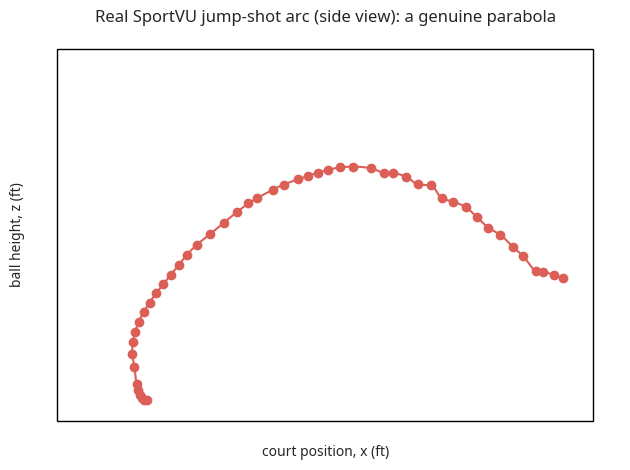

In [4]:
%matplotlib inline
import hypertools as hyp

fig = hyp.plot(arc[['x_ft', 'z_ft']], '-o', reduce=None, ndims=2,
               xlabel='court position, x (ft)', ylabel='ball height, z (ft)',
               title='Real SportVU jump-shot arc (side view): a genuine parabola',
               show=False)
fig

## Part 1: Imputation -- filling occluded and scattered gaps

Optical tracking systems occasionally lose the ball for a few consecutive
frames (occlusion by players, the rim, or a camera dropout), and can also
miss scattered individual samples. We simulate both kinds of damage on a
copy of the real arc:

- **Occlusion**: frames 15-19 (5 consecutive frames) are dropped
  *entirely* -- every one of `x_ft`, `y_ft`, `z_ft` is `NaN` for those
  rows. This is exactly the gap that HyperTools' default `PPCA` imputer
  cannot fill (GH #169): with zero observed features in a row, PPCA has
  nothing to condition its reconstruction on.
- **Scattered noise**: an additional ~10% of individual cells (seeded, for
  reproducibility) are set to `NaN` at random, simulating occasional
  single-camera dropouts.

Both kinds of damage are applied in one call to `hypertools.tools.damage`
(`frac=` for the scattered noise, `rows=` for the occlusion band). We then run
`hyp.impute(damaged, model='Kalman')` and compare the imputed
values against the real, recorded ground truth.

`hyp.impute(damaged, model='Kalman')` returns a frame of the *same shape* as
its input, with every observed cell passed through untouched and only the
`NaN`s replaced. It fits one linear-Gaussian state-space model per column and
runs a Rauch-Tung-Striebel smoother over that column, forward and then
backward across the sequence, so a fully-missing row is reconstructed from
its temporal neighbors rather than from the other columns in that row. That
is exactly why it can bridge the occlusion band, where there are no other
columns left to condition on.

In [5]:
rng = np.random.default_rng(42)

true_arc = arc.copy()

OCCLUSION_SLICE = slice(15, 20)  # 5 consecutive fully-missing frames
# ~10% scattered single-cell dropouts (only among cells still intact after the
# occlusion band), plus the occlusion band itself, via `hypertools.tools.damage`
# (which owns the read-only/Fortran-ordered `.to_numpy()` trap this cell used
# to work around by hand)
damaged = hyp.damage(arc, frac=0.10, rows=OCCLUSION_SLICE, seed=rng)

n_missing = damaged.isna().to_numpy().sum()
print(f'damaged: {n_missing} / {damaged.size} cells missing '
      f'({100 * n_missing / damaged.size:.1f}%), including '
      f'{OCCLUSION_SLICE.stop - OCCLUSION_SLICE.start} fully-NaN rows '
      f'(frames {OCCLUSION_SLICE.start}-{OCCLUSION_SLICE.stop - 1})')
damaged.iloc[13:22]

damaged: 29 / 150 cells missing (19.3%), including 5 fully-NaN rows (frames 15-19)


,x_ft,y_ft,z_ft
t_s,,,
0.519,73.52751,41.21501,9.05020
0.559,73.80681,40.93222,9.56722
0.599,NaN,NaN,NaN
0.640,NaN,NaN,NaN
0.679,NaN,NaN,NaN
0.719,NaN,NaN,NaN
0.760,NaN,NaN,NaN
0.799,76.15129,38.62498,12.99190
0.839,76.66918,38.04769,13.60741


In [6]:
import hypertools as hyp

imputed = hyp.impute(damaged, model='Kalman')

missing_mask = damaged.isna().to_numpy()
rmse_per_axis = np.sqrt(
    np.nanmean(
        np.where(missing_mask,
                 (imputed.to_numpy() - true_arc.to_numpy()) ** 2, np.nan),
        axis=0))
overall_rmse = np.sqrt(
    np.mean((imputed.to_numpy()[missing_mask] - true_arc.to_numpy()[missing_mask]) ** 2))

for col, r in zip(arc.columns, rmse_per_axis):
    print(f'  RMSE[{col}] = {r:.3f} ft (over {missing_mask[:, list(arc.columns).index(col)].sum()} imputed entries)')
print(f'Overall RMSE (all imputed entries, all axes): {overall_rmse:.3f} ft')

occlusion_rmse = np.sqrt(np.mean(
    (imputed.iloc[OCCLUSION_SLICE].to_numpy() - true_arc.iloc[OCCLUSION_SLICE].to_numpy()) ** 2))
print(f'RMSE restricted to the 5 fully-occluded frames: {occlusion_rmse:.3f} ft '
      '(this is the GH #169 gap PPCA cannot fill)')

  RMSE[x_ft] = 0.174 ft (over 9 imputed entries)
  RMSE[y_ft] = 0.222 ft (over 11 imputed entries)
  RMSE[z_ft] = 0.302 ft (over 9 imputed entries)
Overall RMSE (all imputed entries, all axes): 0.237 ft
RMSE restricted to the 5 fully-occluded frames: 0.209 ft (this is the GH #169 gap PPCA cannot fill)


### Imputation, visualized

One panel per coordinate, each drawn by `hyp.plot(..., reduce=None, ndims=1, ax=ax)`:
the true recorded coordinate, the Kalman-imputed one, and (as `x` markers) just the
entries that were imputed -- whether from the occlusion band or a scattered
single-cell dropout. The occluded frames (15-19) are marked by a fourth dataset: the
true values over those frames, drawn as a thick translucent grey stroke
underneath (`color=` and `linewidth=` take one value per dataset). `ndims=1` series
mode draws each dataset directly against its own row index (here, the real frame
number), so there's no more hand-built `(frame, value)` column stack -- a plain
`pd.Series` indexed by frame is enough. Each panel therefore overlays four datasets
already, and the legend/`ylabel` differ per panel, which `panels=` (one dataset per
panel, one shared pipeline) cannot express -- so we keep the explicit-axes form, via
`hyp.subplots`.

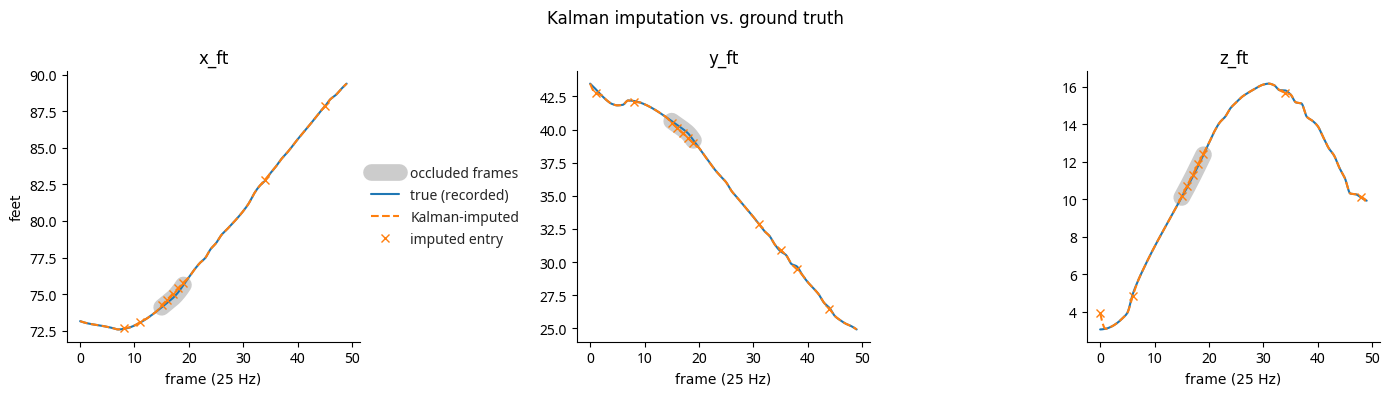

In [7]:
frame = np.arange(len(arc))
fig, axes = hyp.subplots(1, 3, ndims=1, size=[14, 4])

for ax, col in zip(axes, arc.columns):
    miss_idx = np.flatnonzero(missing_mask[:, list(arc.columns).index(col)])
    occluded = pd.Series(true_arc[col].to_numpy()[OCCLUSION_SLICE],
                          index=frame[OCCLUSION_SLICE], name='occluded frames')
    true_series = pd.Series(true_arc[col].to_numpy(), index=frame, name='true (recorded)')
    imputed_series = pd.Series(imputed[col].to_numpy(), index=frame, name='Kalman-imputed')
    imputed_pts = pd.Series(imputed[col].to_numpy()[miss_idx], index=frame[miss_idx],
                             name='imputed entry')

    hyp.plot([occluded, true_series, imputed_series, imputed_pts],
             ['-', '-', '--', 'x'], color=['0.8', 'C0', 'C1', 'C1'], linewidth=[12, 1.5, 1.5, 1],
             reduce=None, ndims=1, ax=ax, title=col,
             xlabel='frame (25 Hz)', ylabel='feet' if col == 'x_ft' else None,
             legend=(['occluded frames', 'true (recorded)', 'Kalman-imputed', 'imputed entry']
                     if col == 'x_ft' else False),
             show=False)

fig.suptitle('Kalman imputation vs. ground truth')
fig.tight_layout()

### Comparing imputers: Kalman vs. scikit-learn's `KNNImputer`

`hyp.impute` also wraps scikit-learn's imputers (`'KNNImputer'`,
`'IterativeImputer'`, `'SimpleImputer'`), so the same call compares them on
the same damage. The comparison makes the Kalman model's advantage concrete.
`KNNImputer` has no notion of time: for each damaged row it looks for the
rows with the most similar *observed* values and averages their entries, and
a row with nothing observed at all cannot be matched to anything, so it gets
the column mean. `IterativeImputer` regresses each column on the others,
which fails the same way on a fully-missing row. The Kalman smoother instead
propagates the ball's state through the gap, which is exactly what a
projectile needs. We score each imputer on the scattered cells and on the
five occluded frames separately, then draw the `y_ft` coordinate (the
ball's position across the court) as an `ndims=1` series against the real
frame number: the true track as a line, and one marker
per imputer at every missing entry, showing where each imputer put the
values it had to invent. (`y_ft` rather than height: the ball's *mean*
height over the arc happens to equal its height inside the gap, so the
column-mean fill would look right there by coincidence.) (Markers rather than
lines, because `hyp.plot` smooths the lines it draws, which would round a
flat run of column-mean fills into a bump.)

          Kalman: RMSE 0.264 ft on scattered cells, 0.209 ft on the occluded frames
      KNNImputer: RMSE 0.589 ft on scattered cells, 4.089 ft on the occluded frames
IterativeImputer: RMSE 3.376 ft on scattered cells, 4.238 ft on the occluded frames


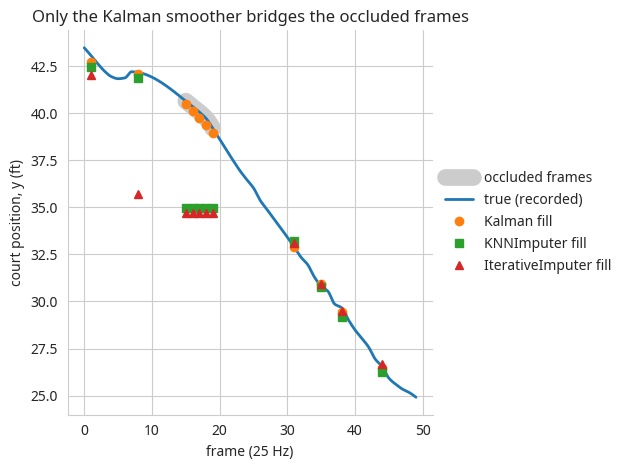

In [8]:
def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

imputations = {'Kalman': imputed}
for model in ('KNNImputer', 'IterativeImputer'):
    imputations[model] = hyp.impute(damaged, model=model)

scattered = missing_mask.copy()
scattered[OCCLUSION_SLICE, :] = False     # scattered single-cell dropouts only
truth = true_arc.to_numpy()
for model, filled in imputations.items():
    values = filled.to_numpy()
    print(f'{model:>16}: RMSE {rmse(values[scattered], truth[scattered]):.3f} ft on scattered cells, '
          f'{rmse(values[OCCLUSION_SLICE], truth[OCCLUSION_SLICE]):.3f} ft on the occluded frames')

miss_y = np.flatnonzero(missing_mask[:, list(arc.columns).index('y_ft')])
occluded = pd.Series(true_arc['y_ft'].to_numpy()[OCCLUSION_SLICE],
                      index=frame[OCCLUSION_SLICE], name='occluded frames')
true_series = pd.Series(true_arc['y_ft'].to_numpy(), index=frame, name='true (recorded)')
fill_series = [pd.Series(filled['y_ft'].to_numpy()[miss_y], index=frame[miss_y],
                          name=f'{model} fill')
               for model, filled in imputations.items()]

fig = hyp.plot([occluded, true_series] + fill_series,
               ['-', '-', 'o', 's', '^'], color=['0.8', 'C0', 'C1', 'C2', 'C3'],
               linewidth=[12, 2, 1, 1, 1], markersize=6, reduce=None, ndims=1,
               xlabel='frame (25 Hz)', ylabel='court position, y (ft)',
               legend=['occluded frames', 'true (recorded)'] + [f'{m} fill' for m in imputations],
               title='Only the Kalman smoother bridges the occluded frames')

## Part 2: Forecasting -- extrapolating the arc's remainder

Now the other direction: given only the **first 30 frames** of the arc
(the rising portion through just past the apex), can `hyp.predict` with a
Kalman model extrapolate the remaining flight? We fit on frames 0-29 and
forecast `t=20` steps ahead, then compare against the actual, recorded
final 20 frames.

In [9]:
FIT_FRAMES = 30
HORIZON = 20  # == len(arc) - FIT_FRAMES

first30 = arc.iloc[:FIT_FRAMES]
actual_tail = arc.iloc[FIT_FRAMES:FIT_FRAMES + HORIZON]

forecast = hyp.predict(first30, model='Kalman', t=HORIZON)

mae_per_axis = np.mean(np.abs(forecast.to_numpy() - actual_tail.to_numpy()), axis=0)
for col, m in zip(arc.columns, mae_per_axis):
    print(f'  MAE[{col}] = {m:.3f} ft')
print(f'Overall MAE (all axes): {np.mean(mae_per_axis):.3f} ft')

  MAE[x_ft] = 3.267 ft
  MAE[y_ft] = 1.590 ft
  MAE[z_ft] = 0.452 ft
Overall MAE (all axes): 1.770 ft


~/hypertools/hypertools/predict/common.py:416: UserWarning: Irregular observation times were linearly interpolated onto a regular grid with step=0.04000000000000001 before fitting this discrete-time forecaster. Pass step= to choose the grid interval; GaussianProcess uses the actual observation times without interpolation.
  self.fit(data)


### Forecast, visualized (side view: x vs. z)

Solid blue is the observed rising portion the model was fit on; solid
green (with circle markers) is the *actual* recorded continuation, drawn
via `truth=`; dashed orange (with x markers) is the Kalman forecast
`hyp.plot` computes itself from `predict=`/`t=` -- one call rather than a
separately-fit forecast hand-assembled into a three-dataset column stack.
`axis_scale='data'` keeps the axes in real court-position/height feet
rather than hypertools' normalized unit frame.

~/hypertools/hypertools/predict/common.py:416: UserWarning: Irregular observation times were linearly interpolated onto a regular grid with step=0.04000000000000001 before fitting this discrete-time forecaster. Pass step= to choose the grid interval; GaussianProcess uses the actual observation times without interpolation.
  self.fit(data)


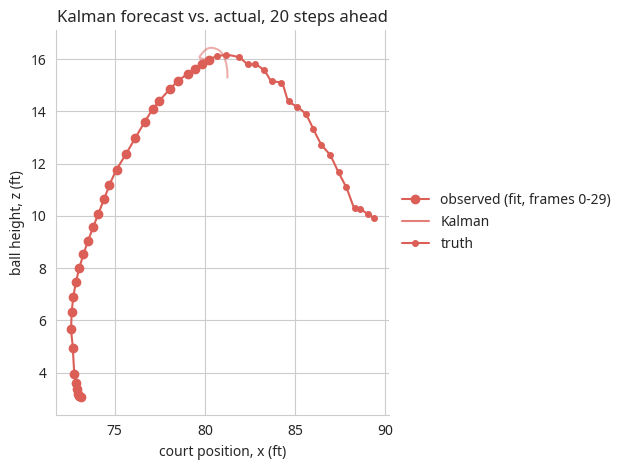

In [10]:
fig = hyp.plot(first30[['x_ft', 'z_ft']], predict='Kalman', t=HORIZON,
               truth=actual_tail[['x_ft', 'z_ft']],
               reduce=None, ndims=2, axis_scale='data', fmt='-o',
               names=['observed (fit, frames 0-29)'], legend=True,
               xlabel='court position, x (ft)', ylabel='ball height, z (ft)',
               title=f'Kalman forecast vs. actual, {HORIZON} steps ahead',
               show=False)
fig

### The same forecast in full 3D, via `hyp.plot`

`hyp.plot(..., predict='Kalman', t=...)` overlays a forecast tail
directly on a HyperTools plot, styled exactly like the observed trace it
continues (same color, linestyle and linewidth) at half its opacity, so it
reads as the same series projected forward. Here we pass the raw `(x, y, z)`
space
through unreduced (`reduce=None`) since the data is already exactly 3
dimensions -- the physical court-plane and height coordinates -- so there's
nothing to project.

~/hypertools/hypertools/predict/common.py:416: UserWarning: Irregular observation times were linearly interpolated onto a regular grid with step=0.04000000000000001 before fitting this discrete-time forecaster. Pass step= to choose the grid interval; GaussianProcess uses the actual observation times without interpolation.
  self.fit(data)


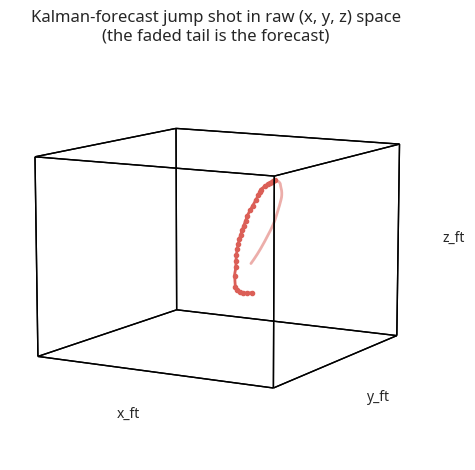

In [11]:
fig = hyp.plot([first30], predict='Kalman', t=HORIZON, reduce=None,
               fmt='-o', markersize=3, linewidth=2,
               title='Kalman-forecast jump shot in raw (x, y, z) space\n(the faded tail is the forecast)')

## Honest takeaways

A constant-velocity/acceleration Kalman model is a genuinely good fit for
this problem *because* the underlying physics matches its assumptions:
during free flight, gravity imposes constant acceleration, so position,
velocity, and acceleration evolve linearly and the noise is well-described
as Gaussian measurement jitter around a smooth trajectory. That's exactly
why it filled the fully-occluded frames well above (something the default
`PPCA` imputer structurally cannot do, per GH #169) and extrapolated the
ball's continuing arc reasonably from only its rising half.

But the same assumptions that make it work here are exactly where it
**breaks down**:

- **Bounces and contact events** (the ball hitting the rim, backboard, or
  floor) introduce near-instantaneous velocity discontinuities that a
  smooth linear-Gaussian model cannot represent -- it will "round off" a
  bounce into a soft curve rather than a sharp reversal.
- **Spin-induced effects** (Magnus force from backspin, rim friction on
  contact) are nonlinear and not part of the constant-acceleration state
  space at all.
- **Air drag** technically makes free-flight deceleration horizontally
  velocity-dependent rather than perfectly constant, which the model
  approximates rather than models exactly (a minor effect at typical shot
  speeds, but not zero).
- **Longer horizons** amplify any of the above: small deviations from the
  ideal ballistic assumption compound the further the model is asked to
  forecast.

In short: trust a Kalman filter for the smooth, ballistic middle of a
flight, and be skeptical of it across bounces, spins, or other contact
events where the physics genuinely changes.

## Next steps

- [`hyp.impute` API reference](../api.rst) and the `plot_impute` gallery
  example.
- [`hyp.predict` API reference](../api.rst) and the `plot_predict` gallery
  example.
- The [stock forecasting tutorial](stock_forecasting.ipynb) applies the
  same `hyp.predict` API to a much less physically-constrained (and much
  harder) forecasting problem: daily equity prices.